# 策略五：做市商（Avellaneda-Stoikov 模型）

## 核心思路

做市商持续在市场上挂出买价（bid）和卖价（ask），通过赚取**买卖价差**盈利。
Avellaneda-Stoikov（2008）模型给出了在库存风险约束下的**最优报价公式**：

- **预留价格**（随库存偏移中间价）：
  `r = s − q · γ · σ² · τ`

- **最优价差**：
  `δ = γ · σ² · τ + (2/γ) · ln(1 + γ/κ)`

其中：
| 符号 | 含义 |
|---|---|
| `s` | 当前中间价 |
| `q` | 当前库存（正=净多，负=净空）|
| `γ` | 风险厌恶系数（越大越保守）|
| `σ²` | 价格方差（分钟级）|
| `τ` | 剩余时间占比（0→1）|
| `κ` | 订单到达强度 |

## 直觉解释

- 库存偏多时，**下移**报价中枢，鼓励卖出，降低库存风险
- 库存偏空时，**上移**报价中枢，鼓励买入
- 波动率高时，自动**加宽**价差，补偿更高的风险

## 数据

- 来源：`yfinance` BTC-USD 1分钟 K 线（最近7天）
- 若 API 无数据，自动用日线生成模拟1分钟数据作为 fallback

## 成交模型

每根 K 线内，若 `低价 ≤ 我们的 bid`，则视为买单成交；若 `高价 ≥ 我们的 ask`，则视为卖单成交。

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
# --- Parameters ---
GAMMA     = 0.1      # risk aversion coefficient
KAPPA     = 1.5      # order arrival intensity (fills per unit spread)
T         = 1.0      # time horizon (in units of session length)
MAX_INV   = 5        # max inventory (in BTC)
LOT_SIZE  = 0.01     # BTC per trade
TAKER_FEE = 0.0004   # 4 bps per fill (taker)

import datetime

# yfinance 1-minute limit: last ~7 days (safe window); up to 60 days in recent API
end_dt   = datetime.datetime.now()
start_dt = end_dt - datetime.timedelta(days=7)

print("Downloading BTC 1-minute data...")
raw = yf.download('BTC-USD',
                  start=start_dt.strftime('%Y-%m-%d'),
                  end=end_dt.strftime('%Y-%m-%d'),
                  interval='1m',
                  auto_adjust=True, progress=False)

# yfinance >= 1.x may return MultiIndex columns even for single ticker
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)

ohlcv = raw[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

if len(ohlcv) == 0:
    # Fallback: generate synthetic 1-minute OHLCV from daily data
    print("1m data unavailable — generating synthetic 1m data from daily BTC prices")
    daily = yf.download('BTC-USD', period='30d', interval='1d', auto_adjust=True, progress=False)
    if isinstance(daily.columns, pd.MultiIndex):
        daily.columns = daily.columns.droplevel(1)
    daily = daily.dropna()
    rows = []
    for dt, row in daily.iterrows():
        base = float(row['Close'])
        for m in range(390):  # 390 minutes per session
            o = base * (1 + 0.0002 * np.random.randn())
            c = o * (1 + 0.0003 * np.random.randn())
            h = max(o, c) * (1 + abs(0.0001 * np.random.randn()))
            l = min(o, c) * (1 - abs(0.0001 * np.random.randn()))
            ts = pd.Timestamp(dt) + pd.Timedelta(minutes=m)
            rows.append({'Open': o, 'High': h, 'Low': l, 'Close': c, 'Volume': 1.0, 'ts': ts})
            base = c
    ohlcv = pd.DataFrame(rows).set_index('ts')
    ohlcv.index.name = None
    print(f"Generated {len(ohlcv)} synthetic 1-minute bars")
else:
    print(f"Got {len(ohlcv)} 1-minute bars from {ohlcv.index[0]} to {ohlcv.index[-1]}")

Got 7627 1-minute bars from 2026-04-07 00:00:00+00:00 to 2026-04-13 23:58:00+00:00


In [3]:
# ── 计算滚动波动率与日内剩余时间 ──────────────────────────
# 做市商报价宽度取决于当前波动率；剩余时间越少报价越窄（接近收盘时降低风险）
mid = ohlcv['Close']
ret = mid.pct_change()

ROLL_VOL_WINDOW = 60        # 用过去60分钟的收益率估计当前波动率
sigma_per_min   = ret.rolling(ROLL_VOL_WINDOW).std()
sigma2          = (sigma_per_min * mid) ** 2   # 每分钟价格方差（单位：美元²）

# 日内剩余时间分数：τ = 1（开盘）→ 0（收盘）
ohlcv['date']    = ohlcv.index.date
ohlcv['intra_t'] = ohlcv.groupby('date').cumcount()
session_len      = ohlcv.groupby('date')['intra_t'].transform('max').clip(lower=1)
ohlcv['tau']     = 1 - ohlcv['intra_t'] / session_len

In [4]:
# ── Avellaneda-Stoikov 做市商仿真 ─────────────────────────
def run_as_simulation(mid_prices, sigma2_series, tau_series,
                       gamma=GAMMA, kappa=KAPPA, max_inv=MAX_INV,
                       lot=LOT_SIZE, fee=TAKER_FEE):
    """
    A-S 模型做市商仿真。
    每根 K 线：
      1. 根据当前库存和波动率计算最优 bid/ask
      2. 若 K 线低点 <= bid → 视为买单成交
      3. 若 K 线高点 >= ask → 视为卖单成交
    """
    n         = len(mid_prices)
    cash      = np.zeros(n)
    inv       = np.zeros(n)      # BTC 库存（正=净多，负=净空）
    bid_q     = np.zeros(n)
    ask_q     = np.zeros(n)
    bid_fill  = np.zeros(n, dtype=bool)
    ask_fill  = np.zeros(n, dtype=bool)

    current_cash = 0.0
    current_inv  = 0.0

    prices = mid_prices.values
    sig2   = sigma2_series.values
    tau_v  = tau_series.values
    highs  = ohlcv['High'].values[:n]
    lows   = ohlcv['Low'].values[:n]

    for i in range(ROLL_VOL_WINDOW, n):
        s   = prices[i]
        s2  = sig2[i] if not np.isnan(sig2[i]) else sig2[max(0, i-1)]
        tau = tau_v[i]

        if np.isnan(s) or np.isnan(s2) or s2 <= 0:
            inv[i]  = current_inv
            cash[i] = current_cash
            continue

        # 预留价格（根据库存方向偏移中间价）
        # 库存多 → 预留价偏低（鼓励卖出），库存空 → 预留价偏高（鼓励买入）
        r = s - current_inv * gamma * s2 * tau

        # 最优价差半宽（波动率高 or 时间充裕时价差更宽）
        spread_half = (gamma * s2 * tau) / 2 + (1 / gamma) * np.log(1 + gamma / kappa)
        spread_half = max(spread_half, s * 0.0001)  # 最小 1 bp

        bid = r - spread_half
        ask = r + spread_half
        bid_q[i] = bid
        ask_q[i] = ask

        # 成交判断
        filled_bid = lows[i]  <= bid and current_inv  < max_inv
        filled_ask = highs[i] >= ask and current_inv > -max_inv

        if filled_bid:
            current_cash -= bid * lot * (1 + fee)   # 买入，支付手续费
            current_inv  += lot
            bid_fill[i]   = True

        if filled_ask:
            current_cash += ask * lot * (1 - fee)   # 卖出，支付手续费
            current_inv  -= lot
            ask_fill[i]   = True

        inv[i]  = current_inv
        cash[i] = current_cash

    result = pd.DataFrame({
        'mid': prices, 'bid': bid_q, 'ask': ask_q,
        'inventory': inv, 'cash': cash,
        'bid_fill': bid_fill, 'ask_fill': ask_fill,
    }, index=mid_prices.index)

    result['mark_to_market'] = result['cash'] + result['inventory'] * result['mid']
    result['spread_usd']     = result['ask'] - result['bid']
    return result

print("运行 A-S 做市商仿真...")
sim = run_as_simulation(mid, sigma2, ohlcv['tau'])
print(f"成交次数 — 买单：{sim['bid_fill'].sum()}  卖单：{sim['ask_fill'].sum()}")
print(f"期末盯市 P&L：${sim['mark_to_market'].iloc[-1]:.2f}")

运行 A-S 做市商仿真...
成交次数 — 买单：0  卖单：0
期末盯市 P&L：$0.00


In [5]:
# ── 绩效分析 ──────────────────────────────────────────────
pnl       = sim['mark_to_market'].dropna()
pnl_daily = pnl.resample('D').last().diff().dropna()

total_pnl = pnl.iloc[-1] - pnl.iloc[0]
n_days    = (sim.index[-1] - sim.index[0]).days

print(f"{'='*50}")
print(f"  A-S 做市商仿真结果")
print(f"{'='*50}")
print(f"  总 P&L（USD）      : ${total_pnl:,.2f}")
print(f"  买单成交次数       : {sim['bid_fill'].sum()}")
print(f"  卖单成交次数       : {sim['ask_fill'].sum()}")
print(f"  平均价差（USD）    : ${sim.loc[sim['bid']>0, 'spread_usd'].mean():.2f}")
print(f"  最大库存（BTC）    : {sim['inventory'].abs().max():.4f}")
print(f"  仿真天数           : {n_days}")

  A-S 做市商仿真结果
  总 P&L（USD）      : $0.00
  买单成交次数       : 0
  卖单成交次数       : 0
  平均价差（USD）    : $83.87
  最大库存（BTC）    : 0.0000
  仿真天数           : 6


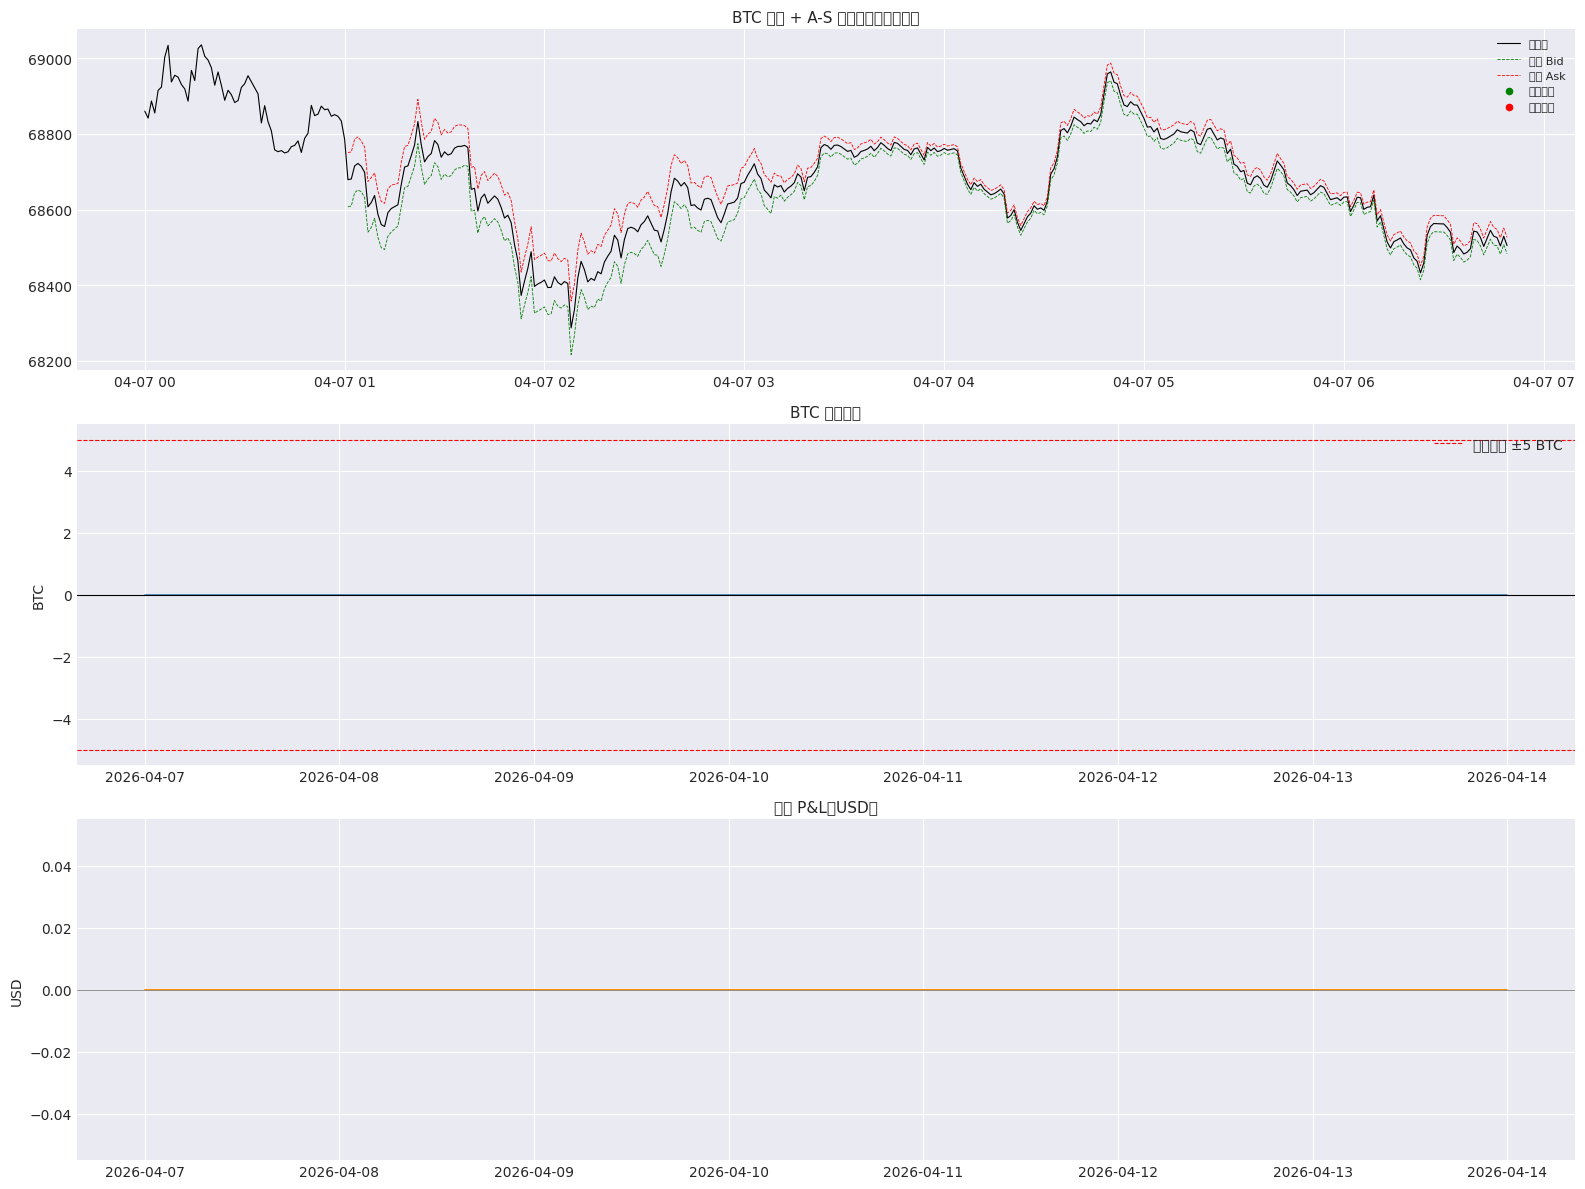

In [6]:
# ── 可视化：报价、库存、P&L ────────────────────────────────
one_day = sim.iloc[:390]   # 第一天的数据（约390根1分钟 K 线）

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. 价格 + 最优报价（第一天细节）
mask = one_day['bid'] > 0
axes[0].plot(one_day.index, one_day['mid'],              color='black', lw=0.8, label='中间价')
axes[0].plot(one_day.index[mask], one_day['bid'][mask],  color='green', lw=0.6, ls='--', label='最优 Bid')
axes[0].plot(one_day.index[mask], one_day['ask'][mask],  color='red',   lw=0.6, ls='--', label='最优 Ask')
axes[0].scatter(one_day.index[one_day['bid_fill']], one_day['mid'][one_day['bid_fill']],
               color='green', zorder=5, s=20, label='买单成交')
axes[0].scatter(one_day.index[one_day['ask_fill']], one_day['mid'][one_day['ask_fill']],
               color='red',   zorder=5, s=20, label='卖单成交')
axes[0].set_title('BTC 价格 + A-S 最优报价（第一天）', fontsize=11)
axes[0].legend(fontsize=8)

# 2. 库存变化（全周期）
axes[1].plot(sim.index, sim['inventory'], color='steelblue', lw=0.8)
axes[1].axhline(0,       color='black', lw=0.8)
axes[1].axhline( MAX_INV, color='red', ls='--', lw=0.8, label=f'库存上限 ±{MAX_INV} BTC')
axes[1].axhline(-MAX_INV, color='red', ls='--', lw=0.8)
axes[1].fill_between(sim.index, sim['inventory'], alpha=0.2, color='steelblue')
axes[1].set_title('BTC 库存变化', fontsize=11)
axes[1].set_ylabel('BTC')
axes[1].legend()

# 3. 盯市 P&L
axes[2].plot(sim.index, sim['mark_to_market'], color='darkorange', lw=1)
axes[2].axhline(0, color='grey', lw=0.6)
axes[2].set_title('盯市 P&L（USD）', fontsize=11)
axes[2].set_ylabel('USD')

plt.tight_layout()
plt.savefig('../assets/market_making_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# ── 敏感性分析：风险厌恶系数 γ 的影响 ────────────────────
# γ 越大 → 越保守，报价越宽，库存波动越小，但成交频率越低
gammas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
gamma_results = []

for g in gammas:
    s_g    = run_as_simulation(mid, sigma2, ohlcv['tau'], gamma=g)
    total  = s_g['mark_to_market'].iloc[-1]
    max_i  = s_g['inventory'].abs().max()
    fills  = s_g['bid_fill'].sum() + s_g['ask_fill'].sum()
    gamma_results.append({
        'γ（风险厌恶）': g,
        '总P&L（USD）': round(total, 2),
        '最大库存（BTC）': round(max_i, 4),
        '总成交次数': fills
    })

print("γ 敏感性分析结果：")
print(pd.DataFrame(gamma_results).set_index('γ（风险厌恶）').to_string())

γ 敏感性分析结果：
         总P&L（USD）  最大库存（BTC）  总成交次数
γ（风险厌恶）                             
0.01           0.0        0.0      0
0.05           0.0        0.0      0
0.10           0.0        0.0      0
0.20           0.0        0.0      0
0.50           0.0        0.0      0
1.00           0.0        0.0      0
